# Aim
The aim of this notebook is to prototype an analysis pipeline for Ari's TUNEL data.

## Overview
3D Immunos for retina stainings, DAPI and TUNEL channels

# 1. Helper functions

In [1]:
import os
os.chdir("..")  # disgusting but quick fix
import limoncello as lc
import pyclesperanto_prototype as cle
from imaris_ims_file_reader.ims import ims
import numpy as np
import os
import re
from tqdm import tqdm
import pyclesperanto_prototype as cle
import matplotlib.pyplot as plt
import napari
from skimage.morphology import skeletonize, medial_axis
from skan.csr import skeleton_to_csgraph, Skeleton, summarize
from skan import draw
from skimage.feature import shape_index
from skimage.measure import regionprops
from scipy.spatial import cKDTree
import pandas as pd
from stackview import insight
from scipy.ndimage import distance_transform_edt

In [2]:

ims_path = r"H:\acuoco\01_lab\B_double mutants\A_experiments\03_cep290-inpp5e\03_TUNEL\TUNEL cep290-inpp5e 3dpf\TUNEL_cep290 mut 3 dpf_Confocal - Blue_Confocal - Yellow_2025-04-08_Protocol 3_13.10.30.ims"

a, meta = lc.load_image(ims_path)


Opening .ims file: \\idnas37.d.uzh.ch\G_MLS_RB_UHome$\acuoco\01_lab\B_double mutants\A_experiments\03_cep290-inpp5e\03_TUNEL\TUNEL cep290-inpp5e 3dpf\TUNEL_cep290 mut 3 dpf_Confocal - Blue_Confocal - Yellow_2025-04-08_Protocol 3_13.10.30.ims
Opening readonly file: \\idnas37.d.uzh.ch\G_MLS_RB_UHome$\acuoco\01_lab\B_double mutants\A_experiments\03_cep290-inpp5e\03_TUNEL\TUNEL cep290-inpp5e 3dpf\TUNEL_cep290 mut 3 dpf_Confocal - Blue_Confocal - Yellow_2025-04-08_Protocol 3_13.10.30.ims 

Shape (T, C, Z, Y, X): (1, 2, 12, 2040, 2040)
Number of timepoints: 1
Number of channels: 2
Image dimensions (Z, Y, X): (12, 2040, 2040)
Z Resolution: 0.917
XY Resolution: (0.152, 0.152)


If for some reason the meta data is not found in the .ims, in many Imaris exports there is a **metadata text file** next to the `.ims` file,
for example:
- `METH-PLTurbID-2h-pfa_2026-02-12_12.33.21.ims`
- `METH-PLTurbID-2h-pfa_2026-02-12_12.33.21_metadata.txt`

This step:
- Looks for a matching `*_metadata.txt` file next to your `.ims`
- Reads voxel sizes (pixel size in µm, Z-step in µm) and channel information
- Stores these values so later steps can report **real volumes in µm³** instead of just voxel counts.

If no metadata file is found, the notebook will keep using default voxel sizes (1.0 µm).

In [3]:
meta_text = lc.load_ims_metadata(ims_path)

Using metadata file:
 H:\acuoco\01_lab\B_double mutants\A_experiments\03_cep290-inpp5e\03_TUNEL\TUNEL cep290-inpp5e 3dpf\TUNEL_cep290 mut 3 dpf_Confocal - Blue_Confocal - Yellow_2025-04-08_Protocol 3_13.10.30_metadata.txt

Pixel size XY: 0.1523 µm
Z step (StepSize): 1.0000 µm
Wavelengths (nm): [445.0, 561.0]

Stored voxel sizes: Z=1.0000 µm, Y=0.1523 µm, X=0.1523 µm


watch out as sometimes the format is inconsistent and resolutions are not found in the txt file they will default to 1

Select GPU for clesperanto library

In [3]:
print(cle.available_device_names(dev_type="gpu"))
cle.select_device('NVIDIA GeForce RTX 4090')  # optional but good practice
print(cle.get_device())

['NVIDIA GeForce RTX 4090', 'gfx1036']
<NVIDIA GeForce RTX 4090 on Platform: NVIDIA CUDA (1 refs)>


In [4]:
# Simple default colormaps for a few channels
DEFAULT_COLORMAPS = ["blue", "magenta"]
CHANNEL_NAMES = ["Nuclei", "TUNEL"]
scale = (meta['voxel_size'])

viewer = napari.Viewer(ndisplay=3)
viewer.dims.axis_labels = ['Z', 'Y', 'X']
def set_layer_scale(event):
    layer = event.value

    if hasattr(layer, 'scale'):

        if layer.ndim == 3:
            layer.scale = scale

        elif layer.ndim == 2:
            layer.scale = (scale[1], scale[2])

# Connect the function to layer insertion events
viewer.layers.events.inserted.connect(set_layer_scale)

T, C, Z, Y, X = a.shape

for c in range(C):
    #volume = (volumes[c] - volumes[c].min()) / (volumes[c].max() - volumes[c].min())  # min - max normalization 
    volume = a[0,c]
    mip = cle.pull(cle.maximum_z_projection(volume))
    cmap = DEFAULT_COLORMAPS[c % len(DEFAULT_COLORMAPS)]
    viewer.add_image(volume, name=f"{CHANNEL_NAMES[c]}", colormap=cmap, blending="additive", scale=scale, units='um')
    viewer.add_image(mip, name=f"MIP {CHANNEL_NAMES[c]}", colormap=cmap, blending="additive", scale=(meta['xy_resolution']), units='um')
print("Napari viewer opened. Use the sliders to explore. Close the window to continue.")
napari.run()


Napari viewer opened. Use the sliders to explore. Close the window to continue.


# Cellpose segmentation

## 3D segmentation
this approach works nicely for segmenting the nuclei, however it is quite slow and probably overkill.

Load the images and denoise with gaussian blur

In [10]:
from skimage.io import imread
import pyclesperanto_prototype as cle  # version 0.24.4
import napari
import numpy as np
from cellpose import models
import napari_segment_blobs_and_things_with_membranes as nsbatwm

if 'viewer' not in globals():
    viewer = napari.Viewer()

image0_N = viewer.layers['Nuclei'].data

# gaussian blur
image1_gbp = cle.gaussian_blur(image0_N, None, 1.0, 1.0, 0.0)
viewer.add_image(
    image1_gbp, name='Result of gaussian_blur (pyclesperanto_prototype)')

# cellpose 3D segmentation using nuclei model on GPU
model = models.CellposeModel(gpu=True, model_type='nuclei')

blurred_np = np.array(image1_gbp)
diam = 90
masks, flows, styles = model.eval(
    blurred_np,
    diameter=diam,       # auto-estimate diameter
    do_3D=True,
    z_axis=0,
    min_size=650,
    channels=[0, 0],     # grayscale input
    anisotropy=meta['z_resolution']/meta['xy_resolution'][0],      # set z/xy ratio if voxels are anisotropic
    progress=True,
    cellprob_threshold=-2,
    flow3D_smooth=2
)
#r=15
#masks = cle.pull(cle.smooth_labels(masks, radius = r))
viewer.add_labels(masks, name=f'Cellpose d={diam}')


model_type argument is not used in v4.0.1+. Ignoring this argument...
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


<Labels layer 'Cellpose d=90 [1]' at 0x1eae3730400>

parm sweep:

In [ ]:
from skimage.io import imread
import pyclesperanto_prototype as cle  # version 0.24.4
import napari
import numpy as np
import pandas as pd
import time
import itertools
from cellpose import models, dynamics
from cellpose.utils import fill_holes_and_remove_small_masks

if 'viewer' not in globals():
    viewer = napari.Viewer()

image0_N = viewer.layers['Nuclei'].data

# ── Gaussian blur ──────────────────────────────────────────────────────────────
image1_gbp = cle.gaussian_blur(image0_N, None, 1.0, 1.0, 0.0)
viewer.add_image(image1_gbp, name='gaussian_blur', visible=True)
blurred_np = np.array(image1_gbp)

anisotropy = meta['z_resolution'] / meta['xy_resolution'][0]

# ── Parameter grid ─────────────────────────────────────────────────────────────
DIAMETERS        = [50, 60, 70, 80, 90, 100]      # each triggers a full model.eval
MIN_SIZES        = [100, 325, 550, 775, 1000]      # post-processing only — free
CELLPROB_THRESH  = [-3, -2, -1, 0, 1, 2, 3]       # post-processing only — free

# Subset added to napari for visual QC (pick representative combos)
VIZ_MIN_SIZES   = [100, 550, 1000]
VIZ_CELLPROB    = [-2, 0, 2]

# ── Model ──────────────────────────────────────────────────────────────────────
model = models.CellposeModel(gpu=True, model_type='nuclei')

results = []   # rows for the summary dataframe

print(f"{'Diam':>6} {'MinSz':>6} {'CPthr':>6} {'nLabels':>8} {'Runtime':>10}")
print("-" * 42)

for diam in DIAMETERS:

    # ── One expensive model.eval per diameter ──────────────────────────────────
    t0 = time.time()
    masks_base, flows, styles = model.eval(
        blurred_np,
        diameter=diam,
        do_3D=True,
        z_axis=0,
        min_size=-1,            # disable internal filter — we apply it ourselves
        channels=[0, 0],
        anisotropy=anisotropy,
        progress=True,
        cellprob_threshold=0,   # neutral threshold for flow computation
        flow3D_smooth=1,
    )
    eval_time = time.time() - t0

    # flows[1] = the cell-probability / distance map used for re-thresholding
    # flows[2] = the 3-D flow field (used by compute_masks)
    cellprob = flows[2]     # shape == image shape, float
    p        = flows[1]     # xyz flows, shape (3, *image.shape)

    # ── Post-processing sweep — milliseconds each ──────────────────────────────
    for min_size, cp_thresh in itertools.product(MIN_SIZES, CELLPROB_THRESH):

        # Re-run mask reconstruction from flows with a different cellprob threshold
        masks_pos = dynamics.compute_masks(
            p,
            cellprob,
            do_3D=True,
            min_size=min_size,
            cellprob_threshold=cp_thresh,
            flow_threshold=0.4,   # keep default
            niter=200,
        )

        # Also apply the hole-fill + min_size filter that cellpose normally does
        masks_post = fill_holes_and_remove_small_masks(masks_pos, min_size=min_size)

        n_labels = int(masks_post.max())

        results.append(dict(
            diameter=diam,
            min_size=min_size,
            cellprob_threshold=cp_thresh,
            n_labels=n_labels,
            eval_time_s=round(eval_time, 1),
        ))

        print(f"{diam:>6} {min_size:>6} {cp_thresh:>6} {n_labels:>8} {round(eval_time, 1):>9.1f}s")

        # ── Add to napari only for the visual-QC subset ────────────────────────
        if min_size in VIZ_MIN_SIZES and cp_thresh in VIZ_CELLPROB:
            layer_name = f'd{diam}_ms{min_size}_cp{cp_thresh:+d}  [{n_labels}]'
            viewer.add_labels(masks_post, name=layer_name, visible=False)

# ── Summary table ──────────────────────────────────────────────────────────────
df = pd.DataFrame(results)
print("\n── Full results ──")
print(df.to_string(index=False))

# Pivot: rows = (diam, min_size), cols = cellprob_threshold
pivot = df.pivot_table(
    index=['diameter', 'min_size'],
    columns='cellprob_threshold',
    values='n_labels',
)
print("\n── n_labels pivot (rows=diam×min_size, cols=cellprob_threshold) ──")
print(pivot.to_string())

# Runtime summary
runtime_summary = df.groupby('diameter')['eval_time_s'].first()
print(f"\n── Eval time per diameter ──\n{runtime_summary.to_string()}")
print(f"\nTotal Cellpose eval time: {runtime_summary.sum():.1f}s  "
      f"({runtime_summary.sum()/60:.1f} min)")

In [5]:
from skimage.io import imread
import pyclesperanto_prototype as cle  # version 0.24.4
import napari
import numpy as np
import pandas as pd
import time
import itertools
from cellpose import models, dynamics
from tqdm import tqdm

if 'viewer' not in globals():
    viewer = napari.Viewer()

image0_N = viewer.layers['Nuclei'].data

# ── Gaussian blur ──────────────────────────────────────────────────────────────
image1_gbp = cle.gaussian_blur(image0_N, None, 1.0, 1.0, 0.0)
viewer.add_image(image1_gbp, name='gaussian_blur', visible=True)
blurred_np = np.array(image1_gbp)

anisotropy = meta['z_resolution'] / meta['xy_resolution'][0]

# ── Parameter grid ─────────────────────────────────────────────────────────────
DIAMETERS       = [50, 60, 70, 80, 90, 100]
CELLPROB_THRESH = [-3, -2, -1, 0, 1, 2, 3]

# ── Model ──────────────────────────────────────────────────────────────────────
model = models.CellposeModel(gpu=True, model_type='nuclei')

results = []

diam_pbar = tqdm(DIAMETERS, desc='Diameters', unit='diam', position=0)

for diam in diam_pbar:
    diam_pbar.set_postfix(diameter=diam)

    # ── One expensive model.eval per diameter ──────────────────────────────────
    t0 = time.time()
    _, flows, _ = model.eval(
        blurred_np,
        diameter=diam,
        do_3D=True,
        z_axis=0,
        min_size=-1,
        channels=[0, 0],
        anisotropy=anisotropy,
        progress=True,
        cellprob_threshold=0,
        flow3D_smooth=1,
    )
    eval_time = time.time() - t0

    cellprob = flows[2]
    p        = flows[1]

    # ── Post-processing sweep ──────────────────────────────────────────────────
    cp_pbar = tqdm(CELLPROB_THRESH, desc=f'  cellprob (d={diam})', unit='thresh',
                   position=1, leave=False)

    for cp_thresh in cp_pbar:
        cp_pbar.set_postfix(cp_thresh=cp_thresh)

        masks= dynamics.compute_masks(
            p,
            cellprob,
            do_3D=True,
            min_size=-1,
            cellprob_threshold=cp_thresh,
            flow_threshold=0.4,
            niter=200,
        )

        n_labels = int(masks.max())

        results.append(dict(
            diameter=diam,
            cellprob_threshold=cp_thresh,
            n_labels=n_labels,
            eval_time_s=round(eval_time, 1),
        ))

        layer_name = f'd{diam}_cp{cp_thresh:+d}  [{n_labels} labels]'
        viewer.add_labels(masks, name=layer_name, visible=False)

# ── Save results ───────────────────────────────────────────────────────────────
df = pd.DataFrame(results)

pivot = df.pivot_table(
    index='diameter',
    columns='cellprob_threshold',
    values='n_labels',
)

csv_path = 'cellpose_sweep_results.csv'
df.to_csv(csv_path, index=False)
print(f"\nResults saved to {csv_path}")

print("\n── n_labels pivot (rows=diameter, cols=cellprob_threshold) ──")
print(pivot.to_string())

runtime_summary = df.groupby('diameter')['eval_time_s'].first()
print(f"\n── Eval time per diameter ──\n{runtime_summary.to_string()}")
print(f"\nTotal Cellpose eval time: {runtime_summary.sum():.1f}s  "
      f"({runtime_summary.sum()/60:.1f} min)")

model_type argument is not used in v4.0.1+. Ignoring this argument...
Diameters: 100%|██████████| 6/6 [1:14:59<00:00, 749.87s/diam, diameter=100]


Results saved to cellpose_sweep_results.csv

── n_labels pivot (rows=diameter, cols=cellprob_threshold) ──
cellprob_threshold      -3      -2      -1       0       1       2       3
diameter                                                                  
50                  2261.0  2250.0  2319.0  2421.0  2555.0  2727.0  2865.0
60                  2166.0  2157.0  2167.0  2277.0  2433.0  2597.0  2588.0
70                  2599.0  2578.0  2654.0  2710.0  2792.0  2826.0  2787.0
80                  2358.0  2336.0  2330.0  2411.0  2503.0  2591.0  2650.0
90                  2181.0  2162.0  2174.0  2209.0  2288.0  2397.0  2485.0
100                 2030.0  2009.0  2030.0  2025.0  2086.0  2210.0  2324.0

── Eval time per diameter ──
diameter
50     289.0
60     202.3
70     172.1
80     116.0
90     103.4
100     73.5

Total Cellpose eval time: 956.3s  (15.9 min)


let's keep d90 cp_thresh -2.

## MIP cellpose segmentation
This approach is much faster but produces some artifacts in the segmentation of the nuclei.

# classical thresholding segmentation

In [5]:
from skimage.io import imread
import pyclesperanto_prototype as cle  # version 0.24.4
import napari
if 'viewer' not in globals():
    viewer = napari.Viewer()

image0_C = viewer.layers['Channel Nuclei'].data

# subtract gaussian background

image1_sgbp = cle.subtract_gaussian_background(image0_C, None, 4.0, 4.0, 4.0)
viewer.add_image(
    image1_sgbp, name='Result of subtract_gaussian_background (pyclesperanto_prototype)')

# voronoi otsu labeling

image2_volp = cle.voronoi_otsu_labeling(image1_sgbp, None, 6.0, 5.0)
viewer.add_labels(
    image2_volp, name='Result of voronoi_otsu_labeling (pyclesperanto_prototype)')

# combine labels

image3_clp = cle.combine_labels(image2_volp, image2_volp)
viewer.add_labels(
    image3_clp, name='Result of combine_labels (pyclesperanto_prototype)')


<Labels layer 'Result of combine_labels (pyclesperanto_prototype) [1]' at 0x1409520cdf0>

# Analysis of labels and TUNEL signal


===== RESULTS =====
Z-score positives: 122 / 1470
Bright fraction positives: 19 / 1470
Positive in BOTH methods: 19 / 1470


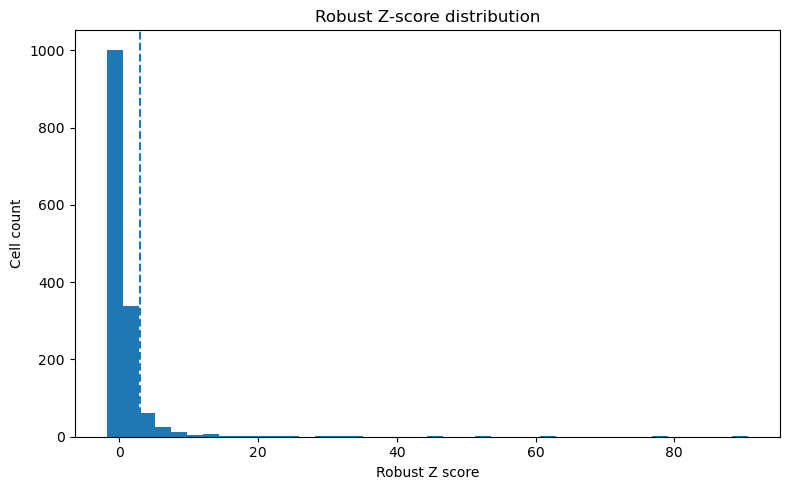

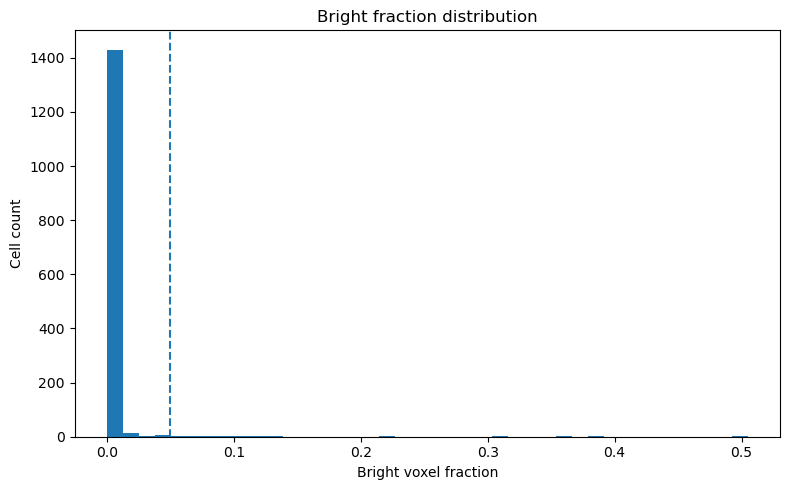

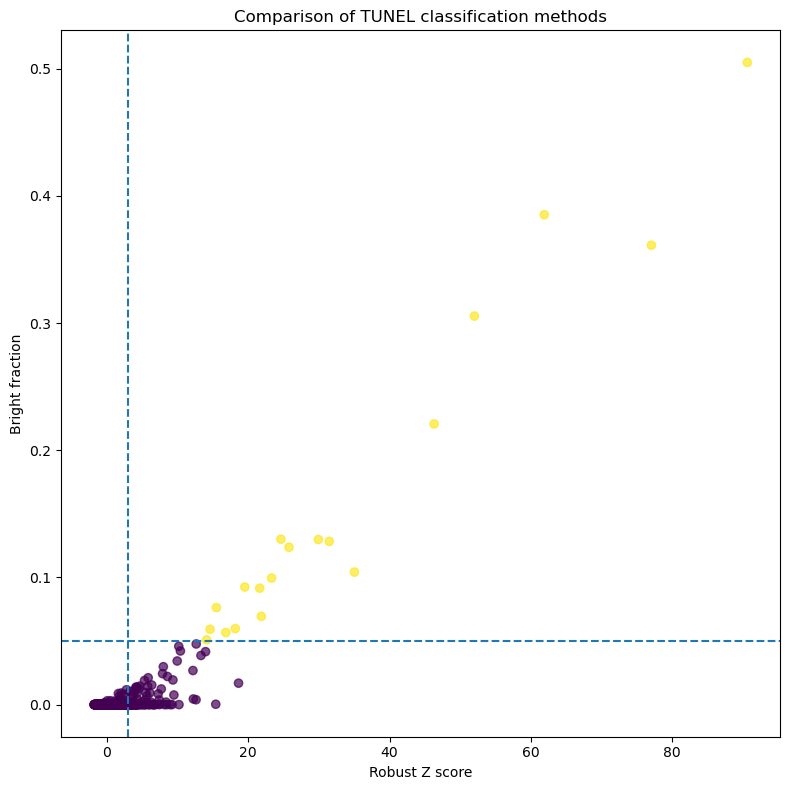

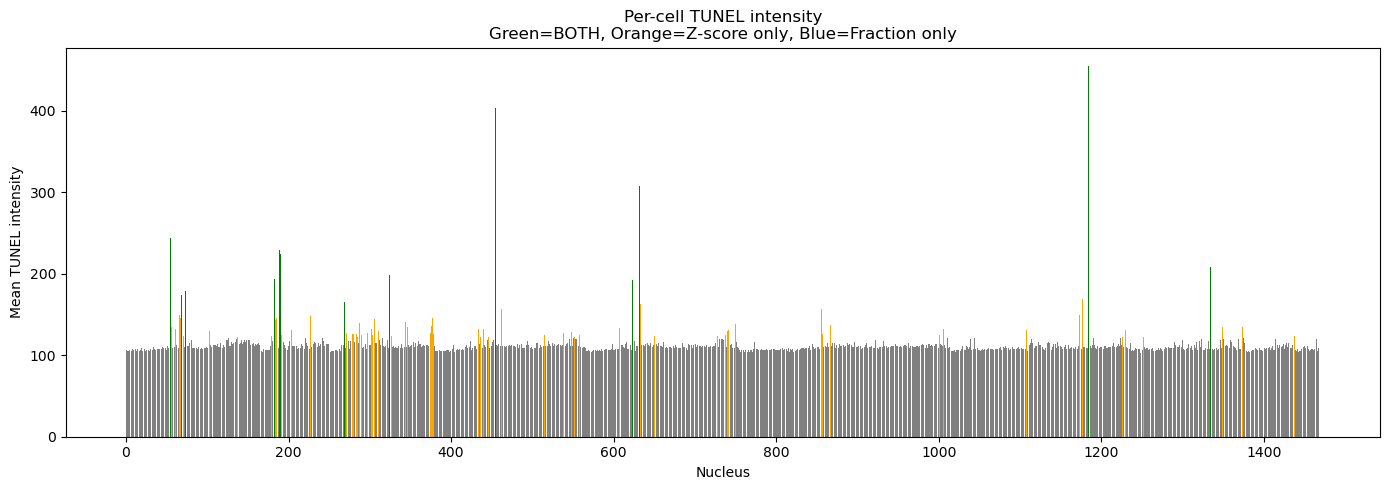

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.filters import threshold_otsu
from scipy.ndimage import distance_transform_edt
from skimage.measure import regionprops_table

# -------------------------------------------------
# INPUTS
# -------------------------------------------------

labels = masks
tunel = viewer.layers['TUNEL'].data

voxel_size = meta['voxel_size']

z_spacing, y_spacing, x_spacing = voxel_size

radius_um = 0

# thresholds
robust_z_threshold = 3
bright_fraction_threshold = 0.05

# -------------------------------------------------
# EXPAND LABELS IN TRUE 3D PHYSICAL SPACE
# -------------------------------------------------

background = labels == 0

distances, nearest_label_coords = distance_transform_edt(
    background,
    sampling=voxel_size,
    return_indices=True
)

expanded_labels = labels[
    tuple(nearest_label_coords)
]

expanded_labels[distances > radius_um] = 0

viewer.add_labels(
    expanded_labels,
    name='Expanded nuclei 3D'
)

# -------------------------------------------------
# MEASURE BASIC FEATURES
# -------------------------------------------------

props = regionprops_table(
    expanded_labels,
    intensity_image=tunel,
    properties=[
        'label',
        'mean_intensity',
        'max_intensity',
        'area',
        'centroid'
    ]
)

df = pd.DataFrame(props)

# -------------------------------------------------
# METHOD 1: ROBUST Z SCORE
# -------------------------------------------------

median_intensity = np.median(df['mean_intensity'])

mad = np.median(
    np.abs(df['mean_intensity'] - median_intensity)
)

# avoid division by zero
mad = max(mad, 1e-8)

df['robust_z'] = (
    0.6745 *
    (df['mean_intensity'] - median_intensity) /
    mad
)

df['positive_zscore'] = (
    df['robust_z'] > robust_z_threshold
)

# -------------------------------------------------
# METHOD 2: BRIGHT FRACTION
# -------------------------------------------------

pixel_threshold = threshold_otsu(tunel)

fractions = []

for label_id in df['label']:

    region = expanded_labels == label_id

    bright_fraction = np.mean(
        tunel[region] > pixel_threshold
    )

    fractions.append(bright_fraction)

df['bright_fraction'] = fractions

df['positive_fraction'] = (
    df['bright_fraction'] > bright_fraction_threshold
)

# -------------------------------------------------
# COMBINED CLASSIFICATION
# -------------------------------------------------

df['positive_both'] = (
    df['positive_zscore'] &
    df['positive_fraction']
)

# -------------------------------------------------
# PRINT COUNTS
# -------------------------------------------------

print("\n===== RESULTS =====")

print(
    f"Z-score positives: "
    f"{df['positive_zscore'].sum()} / {len(df)}"
)

print(
    f"Bright fraction positives: "
    f"{df['positive_fraction'].sum()} / {len(df)}"
)

print(
    f"Positive in BOTH methods: "
    f"{df['positive_both'].sum()} / {len(df)}"
)

# -------------------------------------------------
# CREATE NAPARI LABEL LAYERS
# -------------------------------------------------

zscore_labels = np.zeros_like(expanded_labels)
fraction_labels = np.zeros_like(expanded_labels)
both_labels = np.zeros_like(expanded_labels)

# z-score positives
for label_id in df.loc[
    df['positive_zscore'],
    'label'
]:

    zscore_labels[
        expanded_labels == label_id
    ] = label_id

# bright fraction positives
for label_id in df.loc[
    df['positive_fraction'],
    'label'
]:

    fraction_labels[
        expanded_labels == label_id
    ] = label_id

# overlap positives
for label_id in df.loc[
    df['positive_both'],
    'label'
]:

    both_labels[
        expanded_labels == label_id
    ] = label_id

viewer.add_labels(
    zscore_labels,
    name='TUNEL positive - Z score'
)

viewer.add_labels(
    fraction_labels,
    name='TUNEL positive - Bright fraction'
)

viewer.add_labels(
    both_labels,
    name='TUNEL positive - BOTH'
)

# -------------------------------------------------
# GRAPH 1: ROBUST Z SCORE DISTRIBUTION
# -------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df['robust_z'],
    bins=40
)

ax.axvline(
    robust_z_threshold,
    linestyle='--'
)

ax.set_xlabel('Robust Z score')
ax.set_ylabel('Cell count')
ax.set_title('Robust Z-score distribution')

plt.tight_layout()
plt.show()

# -------------------------------------------------
# GRAPH 2: BRIGHT FRACTION DISTRIBUTION
# -------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df['bright_fraction'],
    bins=40
)

ax.axvline(
    bright_fraction_threshold,
    linestyle='--'
)

ax.set_xlabel('Bright voxel fraction')
ax.set_ylabel('Cell count')
ax.set_title('Bright fraction distribution')

plt.tight_layout()
plt.show()

# -------------------------------------------------
# GRAPH 3: METHOD COMPARISON SCATTER
# -------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

scatter = ax.scatter(
    df['robust_z'],
    df['bright_fraction'],
    c=df['positive_both'],
    alpha=0.7
)

ax.axvline(
    robust_z_threshold,
    linestyle='--'
)

ax.axhline(
    bright_fraction_threshold,
    linestyle='--'
)

ax.set_xlabel('Robust Z score')
ax.set_ylabel('Bright fraction')
ax.set_title('Comparison of TUNEL classification methods')

plt.tight_layout()
plt.show()

# -------------------------------------------------
# GRAPH 4: MEAN INTENSITY BARPLOT
# -------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

colors = []

for _, row in df.iterrows():

    if row['positive_both']:
        colors.append('green')

    elif row['positive_zscore']:
        colors.append('orange')

    elif row['positive_fraction']:
        colors.append('blue')

    else:
        colors.append('gray')

ax.bar(
    np.arange(len(df)),
    df['mean_intensity'],
    color=colors
)

ax.set_xlabel('Nucleus')
ax.set_ylabel('Mean TUNEL intensity')
ax.set_title(
    'Per-cell TUNEL intensity\n'
    'Green=BOTH, Orange=Z-score only, Blue=Fraction only'
)

plt.tight_layout()
plt.show()

# -------------------------------------------------
# OPTIONAL: SAVE RESULTS
# -------------------------------------------------

# df.to_csv("tunel_quantification.csv", index=False)

In [12]:
import numpy as np

# -------------------------------------------------
# PARAMETERS
# -------------------------------------------------

df_plot = df[df['positive_fraction']]

# -------------------------------------------------
# BUILD POSITIVE-CELLS LABEL VOLUME
# -------------------------------------------------

# get the shape from the expanded labels
positive_labels = np.zeros_like(expanded_labels)

for _, row in df_plot.iterrows():
    label_id = int(row['label'])
    positive_labels[expanded_labels == label_id] = label_id

# -------------------------------------------------
# ADD TO NAPARI
# -------------------------------------------------

viewer.add_labels(
    positive_labels,
    name=f'TUNEL positive ({len(df_plot)} cells)',
)

<Labels layer 'TUNEL positive (19 cells)' at 0x1e9e5b92aa0>

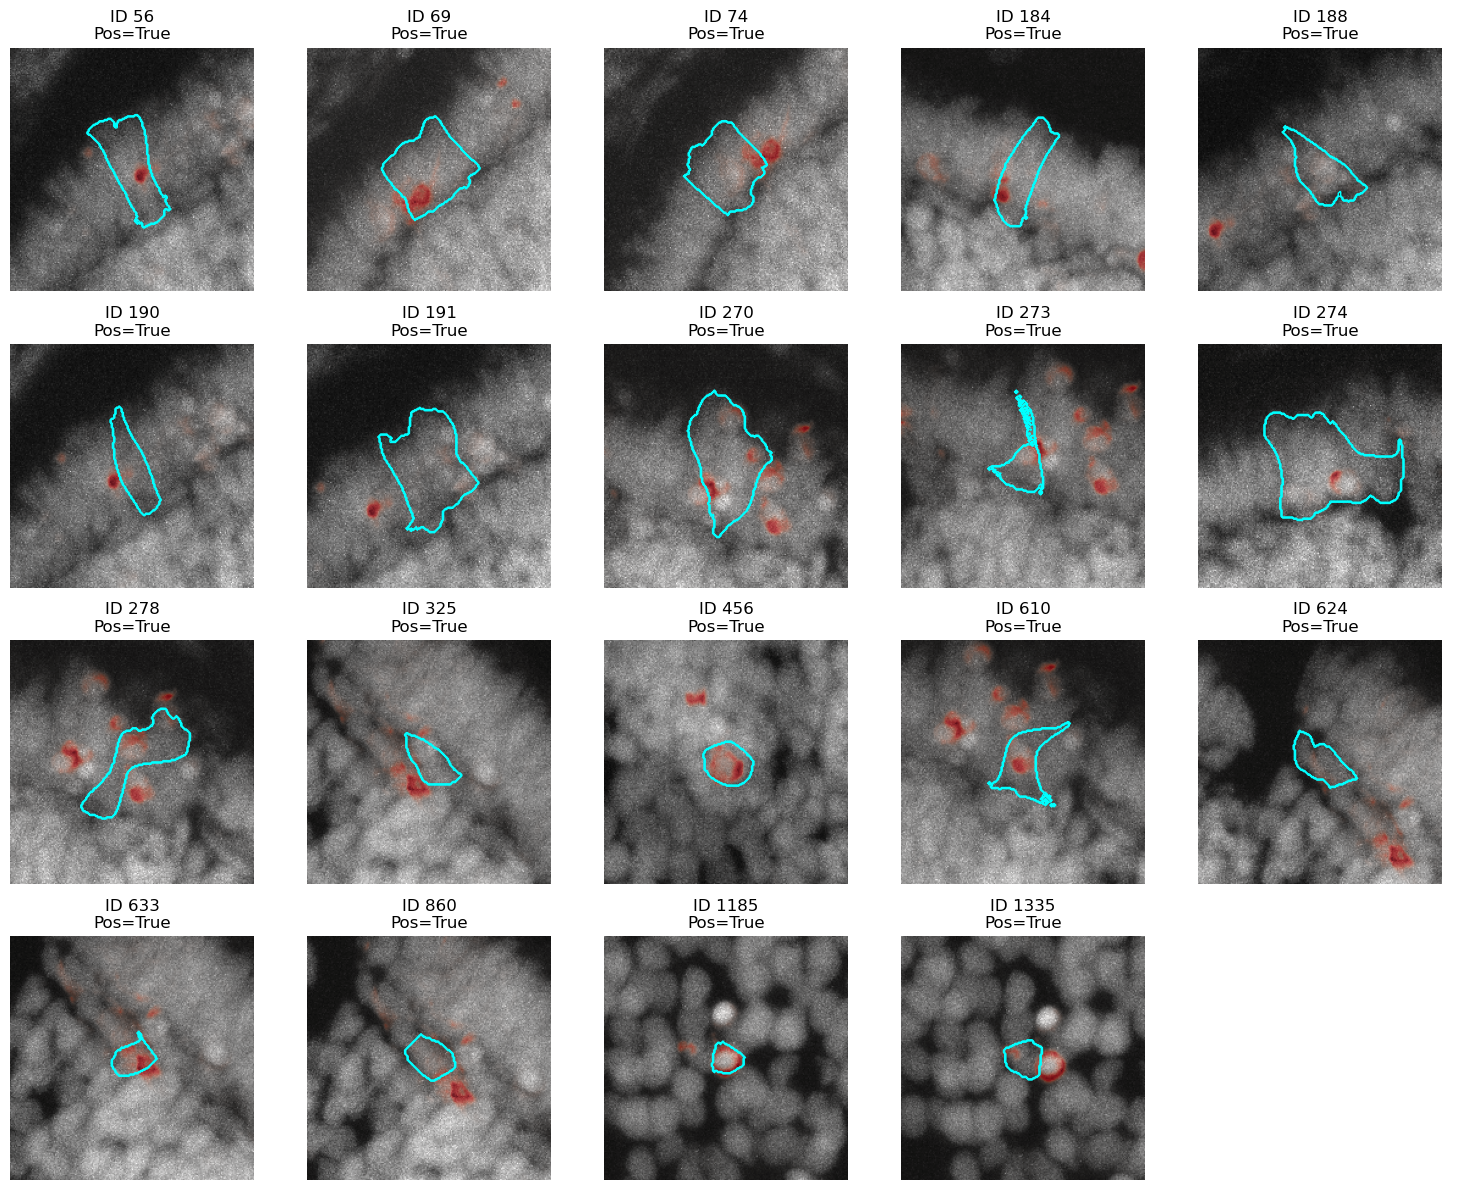

In [14]:
import math
from skimage.segmentation import find_boundaries
# -------------------------------------------------
# PARAMETERS
# -------------------------------------------------

crop_size = 100      # XY crop size in pixels
z_window = 10        # slices around centroid

n_cells = len(df)

# choose only positive cells if desired
df_plot = df[df['positive_fraction']]


# original images
nuclei = viewer.layers['Nuclei'].data
nuclei_img = cle.pull(nuclei)
tunel_img = cle.pull(tunel)

# -------------------------------------------------
# GRID SETUP
# -------------------------------------------------

ncols = 5
nrows = math.ceil(len(df_plot) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(3*ncols, 3*nrows)
)

axes = np.ravel(axes)

# -------------------------------------------------
# LOOP THROUGH CELLS
# -------------------------------------------------

for ax, (_, row) in zip(axes, df_plot.iterrows()):

    zc = int(row['centroid-0'])
    yc = int(row['centroid-1'])
    xc = int(row['centroid-2'])

    # define crop bounds
    z0 = max(0, zc - z_window)
    z1 = min(nuclei_img.shape[0], zc + z_window)

    y0 = max(0, yc - crop_size)
    y1 = min(nuclei_img.shape[1], yc + crop_size)

    x0 = max(0, xc - crop_size)
    x1 = min(nuclei_img.shape[2], xc + crop_size)
    
    # crop stacks
    nuclei_crop = nuclei_img[z0:z1, y0:y1, x0:x1]
    tunel_crop = tunel_img[z0:z1, y0:y1, x0:x1]

    # max projections
    nuclei_proj = np.max(nuclei_crop, axis=0)
    tunel_proj = np.max(tunel_crop, axis=0)

    # normalize
    nuclei_proj = nuclei_proj.astype(float)
    tunel_proj = tunel_proj.astype(float)

    nuclei_proj /= nuclei_proj.max() + 1e-8
    tunel_proj /= tunel_proj.max() + 1e-8

    # -------------------------------------------------
    # CREATE MASK FOR THIS NUCLEUS (from expanded labels)
    # -------------------------------------------------

    label_id = int(row['label'])

    mask_crop = (expanded_labels[z0:z1, y0:y1, x0:x1] == label_id)

    mask_proj = np.max(mask_crop, axis=0)

    # find boundary pixels
    boundaries = find_boundaries(mask_proj, mode='outer')

    # -------------------------------------------------
    # PLOT
    # -------------------------------------------------

    ax.imshow(nuclei_proj, cmap='gray')

    ax.imshow(
        tunel_proj,
        cmap='Reds',
        alpha=tunel_proj * 0.8
    )

    # overlay outline (white or cyan, pick your emotional state)
    ax.contour(
        boundaries,
        colors='cyan',
        linewidths=1
    )

    ax.set_title(
        f"ID {label_id}\nPos={row['positive_fraction']}"
    )

    ax.axis('off')

# remove unused axes
for ax in axes[len(df_plot):]:
    ax.axis('off')

plt.tight_layout()
plt.show()